In [ ]:
#============================
# HR Attrition Analysis
#=============================

In [20]:
import pandas as pd
import matplotlib .pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [4]:
# set style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(10,6)
plt.rcParams['font.size']=12



In [5]:
#load cleaned data set
df=pd.read_csv("C:\\Users\\SSS\\OneDrive\\Desktop\\hr-attrition-analysis\\data\\processed\\hr_attriton_cleaned.csv")
print(f"data loaded-shape:{df.shape}")

data loaded-shape:(1470, 33)


overall attrition rate:0.16%


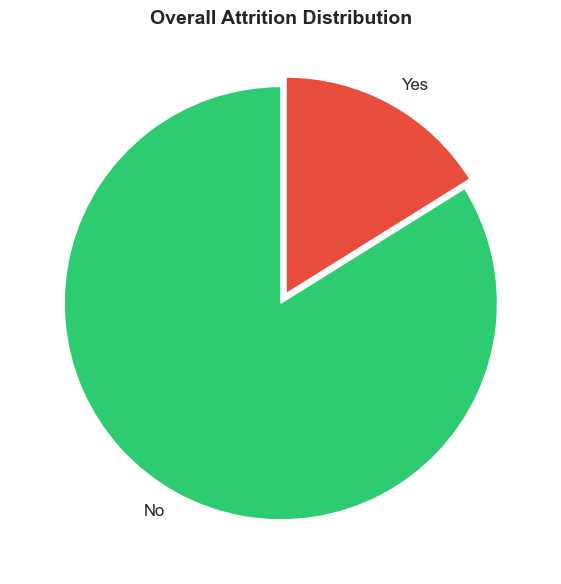

In [6]:
#---------------------------------------
# 1.overall attrition rate
#---------------------------------------
attrition_rate=df["Attrition_flag"].mean()
print(f"overall attrition rate:{attrition_rate:.2f}%")
#plot
color=['#2ecc71','#e74c3c']
df['Attrition'].value_counts().plot(
    kind='pie',
    colors=color,
    startangle=90,
    explode=(0,0.05)
)
plt.title("Overall Attrition Distribution",fontsize=14,fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.savefig("C:\\Users\\SSS\\OneDrive\\Desktop\\hr-attrition-analysis\\reports\\01_attrition_distribution,png")
plt.show()

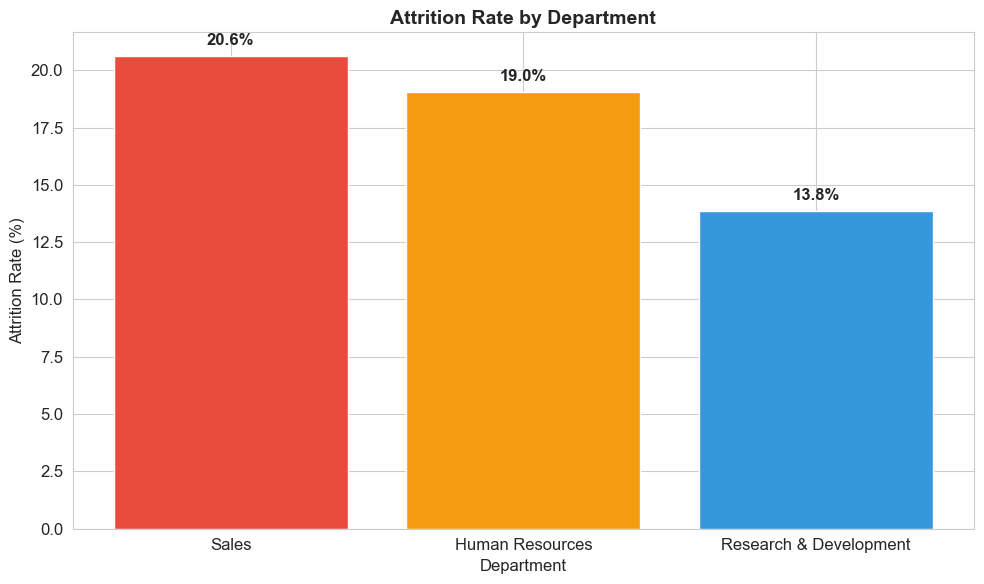

In [7]:
#---------------------------------------
# 2. attrition by department
#---------------------------------------
dept_attrition=df.groupby('Department')['Attrition_flag'].mean()*100
dept_attrition=dept_attrition.sort_values(ascending=False)

plt.Figure(figsize=(10,5))
bars=plt.bar(dept_attrition.index,dept_attrition.values,color=['#e74c3c','#f39c12','#3498db'])
plt.title("Attrition Rate by Department",fontsize=14,fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
for bar,val in zip(bars,dept_attrition.values):
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.5,
             f'{val:.1f}%',ha='center',fontweight='bold')
plt.savefig("C:\\Users\\SSS\\OneDrive\\Desktop\\hr-attrition-analysis\\reports\\02_attrition_rate by department.png")
plt.tight_layout()
plt.show()

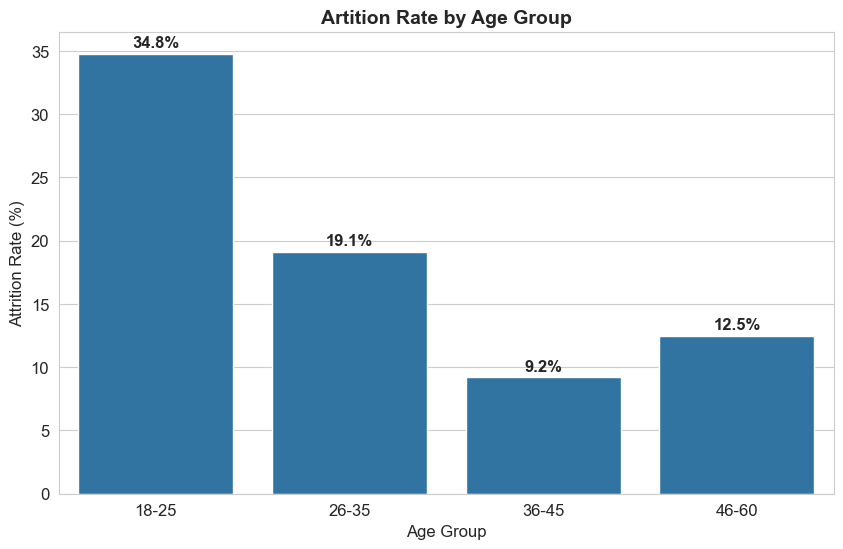

In [8]:
#---------------------------------------
# 3. attrition by age group
#---------------------------------------
df['Age_group']=pd.cut(df['Age'],bins=[18,25,35,45,60],
                       labels=['18-25','26-35','36-45','46-60'])
age_attrition=df.groupby('Age_group')['Attrition_flag'].mean()*100
plt.Figure(figsize=(10,5))
sns.barplot(x=age_attrition.index,y=age_attrition.values)
plt.title('Artition Rate by Age Group',fontsize=14,fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Attrition Rate (%)')
for i,val in enumerate(age_attrition.values):
    plt.text(i,val+0.5,f'{val:.1f}%',ha='center',fontweight='bold')
plt.savefig("C:\\Users\\SSS\\OneDrive\\Desktop\\hr-attrition-analysis\\reports\\03_attrition_rate_by_Age.png")
plt.show()

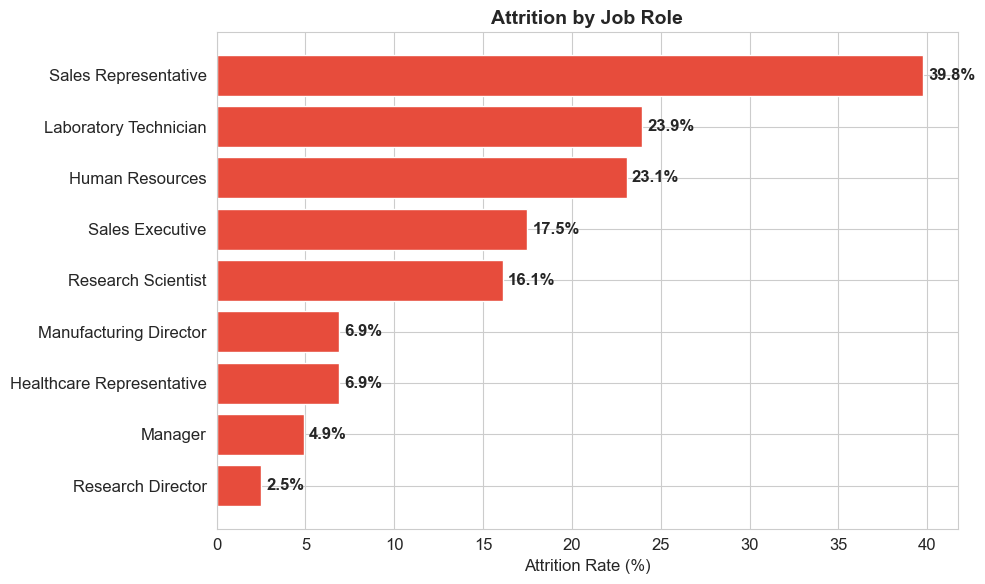

In [9]:
#---------------------------------------
# 4. attrition by job role
#---------------------------------------
role_attrition=df.groupby("JobRole")["Attrition_flag"].mean()*100
role_attrition=role_attrition.sort_values(ascending=True)
plt.Figure(figsize=(10,7))
plt.title("Attrition by Job Role",fontsize=14,fontweight='bold')
bars=plt.barh(role_attrition.index,role_attrition.values,color='#e74c3c')
plt.xlabel('Attrition Rate (%)')
for bar,val in zip(bars,role_attrition.values):
    plt.text(val+0.3,bar.get_y()+bar.get_height()/2,
             f'{val:.1f}%',va='center',fontweight='bold')
plt.tight_layout()
plt.savefig("C:\\Users\\SSS\\OneDrive\\Desktop\\hr-attrition-analysis\\reports\\04_attrition_rate_by_jobrole")
plt.show()

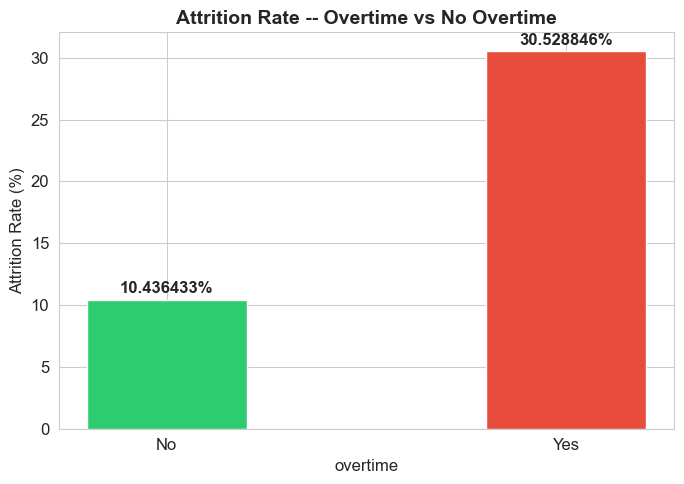

In [27]:
#---------------------------------------
# 5. overtime vs attrition 
#---------------------------------------
overtime_attrition=df.groupby('OverTime')['Attrition_flag'].mean()*100
plt.figure(figsize=(7,5))
bars=plt.bar(overtime_attrition.index,overtime_attrition.values,color=['#2ecc71','#e74c3c'],width=0.4)
plt.title("Attrition Rate -- Overtime vs No Overtime",fontsize=14,fontweight='bold')
plt.xlabel('overtime')
plt.ylabel('Attrition Rate (%)')
for bar ,val in zip(bars,overtime_attrition.values):
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.5,
             f'{val:1f}%',ha='center',fontweight='bold')
plt.tight_layout()
plt.savefig("C:\\Users\\SSS\\OneDrive\\Desktop\\hr-attrition-analysis\\reports\\05_overtime_vs_attrition.png")
plt.show()


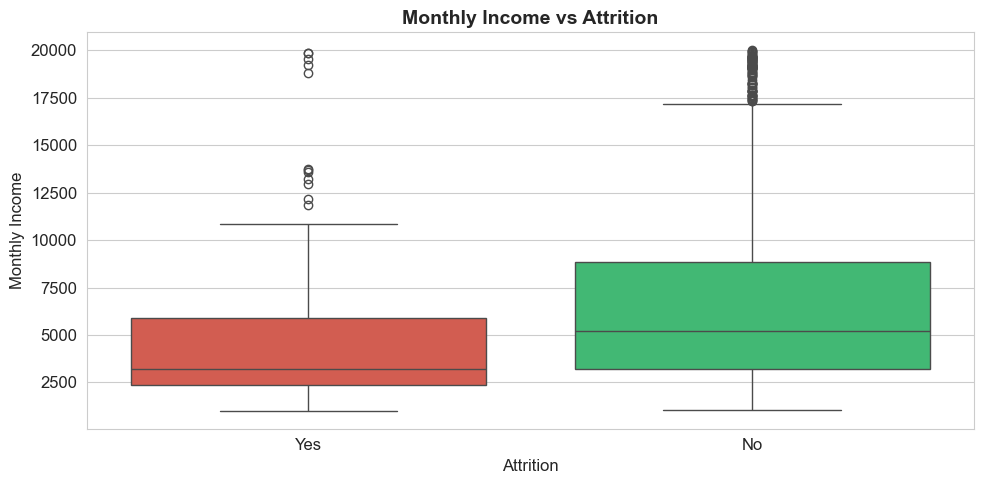

In [30]:
#---------------------------------------
# 6. monthly income vs attrition 
#---------------------------------------
plt.figure(figsize=(10,5))
sns.boxplot(x='Attrition',y='MonthlyIncome',data=df,
            hue='Attrition',
            palette={'Yes':'#e74c3c','No':'#2ecc71'},
                     legend=False)
plt.title('Monthly Income vs Attrition',fontsize=14,fontweight='bold')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')
plt.tight_layout()
plt.savefig("C:\\Users\\SSS\\OneDrive\\Desktop\\hr-attrition-analysis\\reports\\06_monthlyIncome_vs_attrition.png")
plt.show()

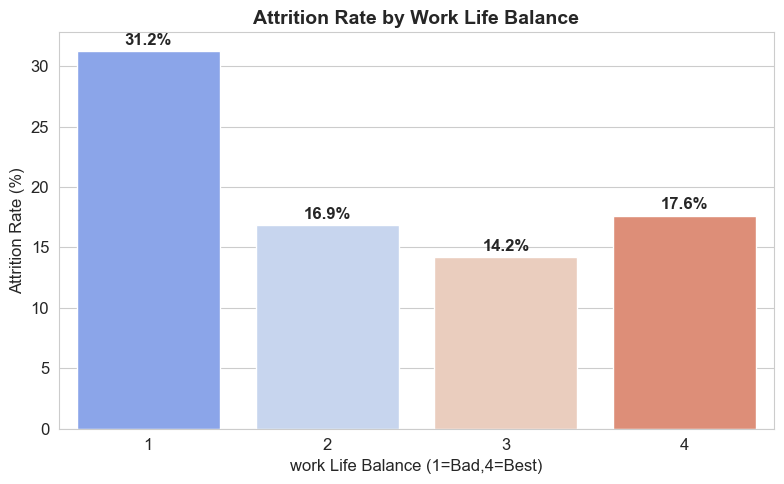

In [28]:
#---------------------------------------
# 7.  work life balance vs attrition 
#---------------------------------------
wlb_attrition=df.groupby('WorkLifeBalance')['Attrition_flag'].mean()*100
plt.figure(figsize=(8,5))
sns.barplot(x=wlb_attrition.index,y=wlb_attrition.values,palette='coolwarm')
plt.title('Attrition Rate by Work Life Balance',fontsize=14,fontweight='bold')
plt.xlabel('work Life Balance (1=Bad,4=Best)')
plt.ylabel('Attrition Rate (%)')
for i,val in enumerate(wlb_attrition.values):
    plt.text(i,val+0.5,f'{val:.1f}%',ha='center',fontweight='bold')
plt.tight_layout()
plt.savefig("C:\\Users\\SSS\\OneDrive\\Desktop\\hr-attrition-analysis\\reports\\07_work_life_balance_vs_attrition.png")             
plt.show()

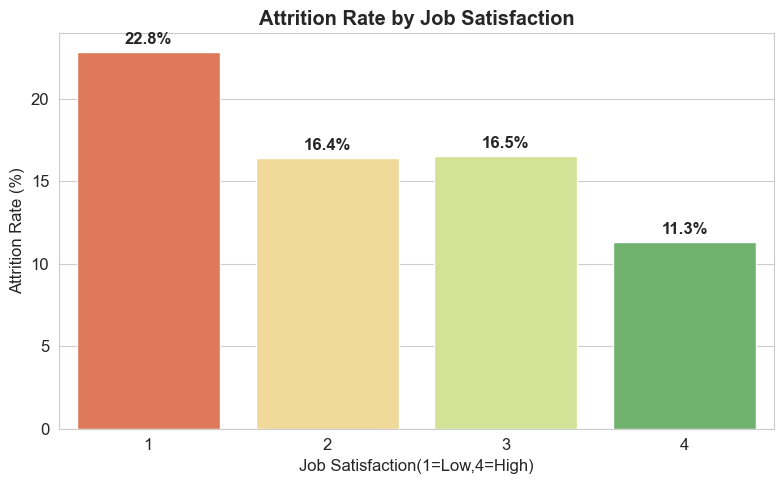

In [31]:
#---------------------------------------
# 8.  Job satisfaction  vs attrition 
#---------------------------------------
js_attrition=df.groupby('JobSatisfaction')['Attrition_flag'].mean()*100
plt.figure(figsize=(8,5))
sns.barplot(x=js_attrition.index,y=js_attrition.values,palette='RdYlGn')
plt.title("Attrition Rate by Job Satisfaction",fontweight='bold')
plt.xlabel('Job Satisfaction(1=Low,4=High)')
plt.ylabel('Attrition Rate (%)')
for i,val in enumerate(js_attrition.values):
    plt.text(i,val+0.5,f'{val:.1f}%',ha='center',fontweight='bold')
plt.tight_layout()
plt.savefig("C:\\Users\\SSS\\OneDrive\\Desktop\\hr-attrition-analysis\\reports\\08_job_satisfaction_vs_attrition.png")
plt.show()

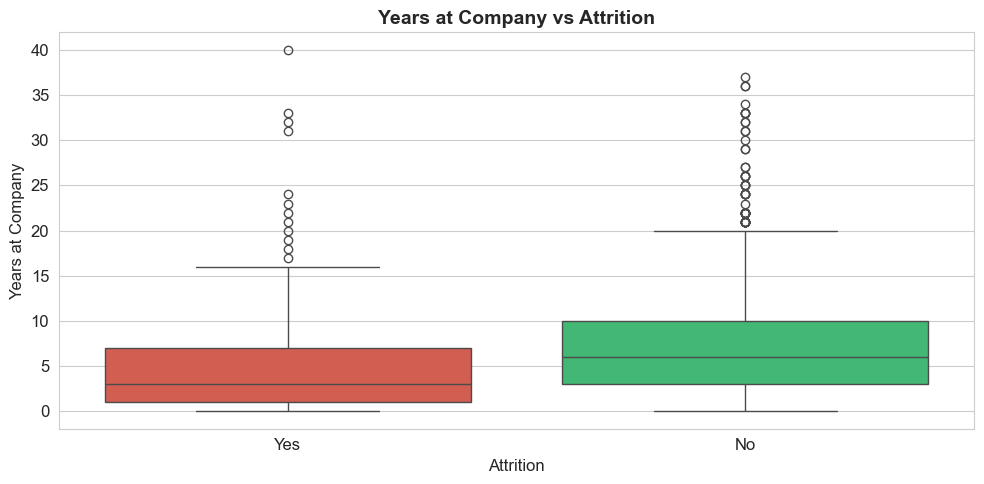

In [34]:
# ----------------------------------------
# 9. YEARS AT COMPANY vs ATTRITION
# ----------------------------------------
plt.figure(figsize=(10, 5))
sns.boxplot(x='Attrition', y='YearsAtCompany', data=df,
            palette={'Yes': '#e74c3c', 'No': '#2ecc71'})
plt.title('Years at Company vs Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Attrition')
plt.ylabel('Years at Company')

plt.tight_layout()
plt.savefig('C:\\Users\\SSS\\OneDrive\\Desktop\\hr-attrition-analysis\\reports\\09_years_vs_attrition.png', dpi=150)
plt.show()

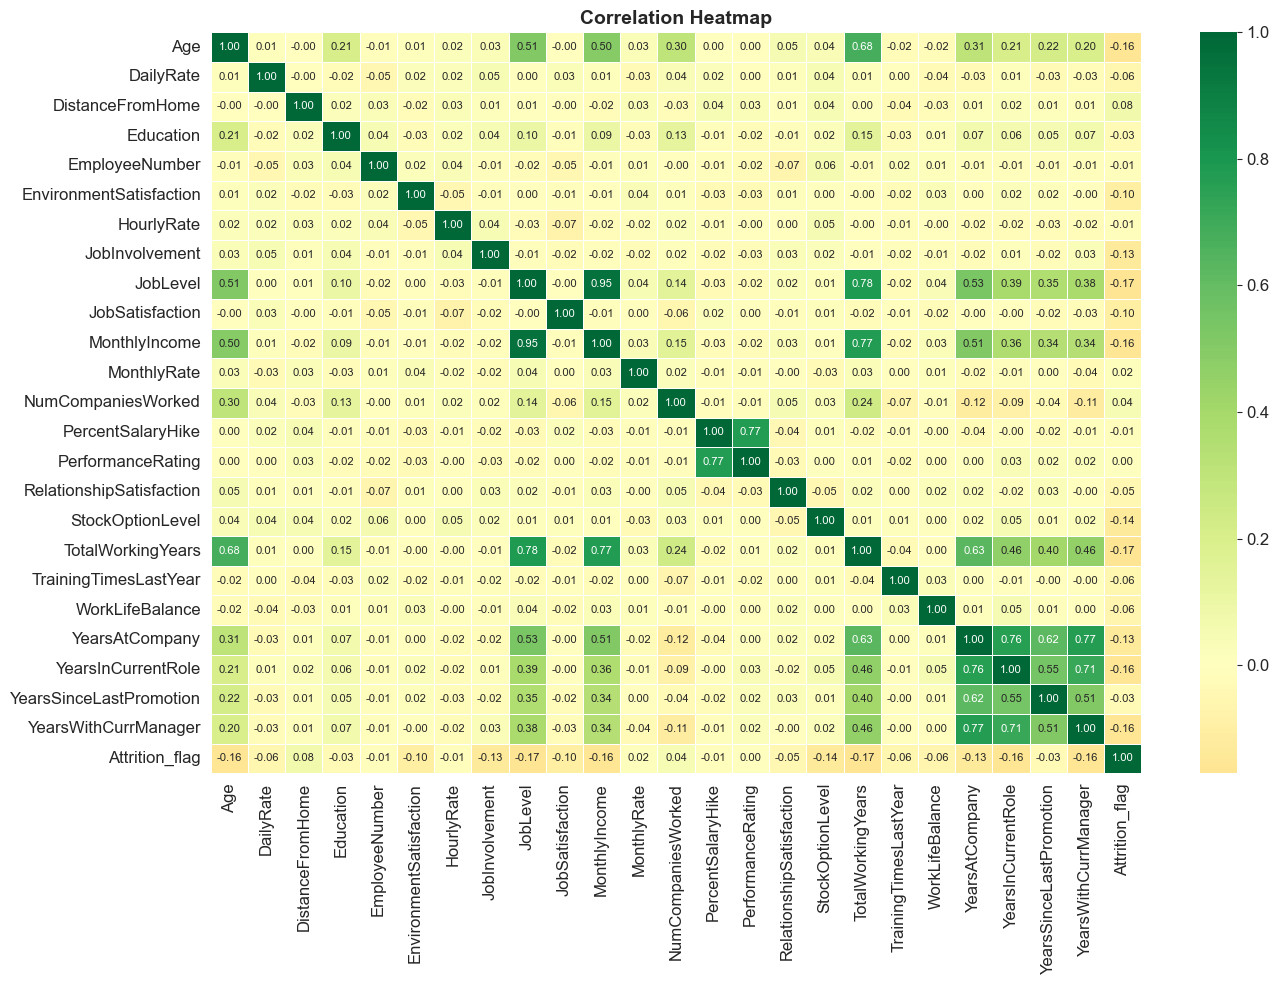

In [32]:
# ----------------------------------------
# 10. CORRELATION HEATMAP
# ----------------------------------------
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_df.corr()

sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            linewidths=0.5,
            annot_kws={'size': 8})

plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('C:\\Users\\SSS\\OneDrive\\Desktop\\hr-attrition-analysis\\reports\\10_correlation_heatmap.png', dpi=150)
plt.show()